## Candidate contributions over time

We'll start with the District 11 congressional candidates, then move on the the Senate candidates.

In [6]:
import pandas as pd, numpy as np, altair as alt, os

import glob

In [7]:
min_date = '2019-08-23'
max_date='2019-12-31'

idx = pd.date_range(min_date, max_date, freq='D')
idx

DatetimeIndex(['2019-08-23', '2019-08-24', '2019-08-25', '2019-08-26',
               '2019-08-27', '2019-08-28', '2019-08-29', '2019-08-30',
               '2019-08-31', '2019-09-01',
               ...
               '2019-12-22', '2019-12-23', '2019-12-24', '2019-12-25',
               '2019-12-26', '2019-12-27', '2019-12-28', '2019-12-29',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[ns]', length=131, freq='D')

In [8]:
d = {
    os.path.splitext(
        os.path.basename(f))[0] : pd.read_csv(
            f, 
            parse_dates=['contribution_receipt_date'], 
            usecols=['contribution_receipt_date', 'contribution_receipt_amount']
        ) for f in glob.glob('fec/conts/*.csv')}

In [9]:
hogg = d['hogg'].rename(columns={'contribution_receipt_date': 'Date', 'contribution_receipt_amount':'Amount'})
breyman = d['breyman'].rename(columns={'contribution_receipt_date': 'Date', 'contribution_receipt_amount':'Amount'})
bartlett = d['bartlett'].rename(columns={'contribution_receipt_date': 'Date', 'contribution_receipt_amount':'Amount'})
pfluger = d['pfluger'].rename(columns={'contribution_receipt_date': 'Date', 'contribution_receipt_amount':'Amount'})

cornyn = d['cornyn'].rename(columns={'contribution_receipt_date': 'Date', 'contribution_receipt_amount':'Amount'})
hegar = d['hegar'].rename(columns={'contribution_receipt_date': 'Date', 'contribution_receipt_amount':'Amount'})

In [10]:
df_list = [hogg, breyman, bartlett, pfluger]

for df in df_list:
    df.sort_values('Date', ascending = True)

In [11]:
hogg = hogg.groupby('Date')[['Amount']].sum()
bartlett = bartlett.groupby('Date')[['Amount']].sum()
breyman = breyman.groupby('Date')[['Amount']].sum()
pfluger = pfluger.groupby('Date')[['Amount']].sum()

cornyn = cornyn.groupby('Date')[['Amount']].sum()
hegar = hegar.groupby('Date')[['Amount']].sum()

## Split candidates

Now we'll split between House and Senate candidates because the time period is so different

In [12]:
hogg = hogg.reindex(idx, fill_value=0).rename_axis('Date')
bartlett = bartlett.reindex(idx, fill_value=0).rename_axis('Date')
breyman = breyman.reindex(idx, fill_value=0).rename_axis('Date')
pfluger = pfluger.reindex(idx, fill_value=0).rename_axis('Date')

hogg

,Amount
Date,
2019-08-23,500.0
2019-08-24,0.0
2019-08-25,0.0
2019-08-26,0.0
2019-08-27,0.0
2019-08-28,0.0
2019-08-29,0.0
2019-08-30,0.0
2019-08-31,0.0


In [13]:
hogg_amount_series = pd.Series(hogg['Amount'])
bartlett_amount_series = pd.Series(bartlett['Amount'])
breyman_amount_series = pd.Series(breyman['Amount'])
pfluger_amount_series = pd.Series(pfluger['Amount'])

h_cuml = hogg_amount_series.cumsum()
ba_cuml = bartlett_amount_series.cumsum()
br_cuml = breyman_amount_series.cumsum()
p_cuml = pfluger_amount_series.cumsum()

hogg['Running Total'] = h_cuml
bartlett['Running Total'] = ba_cuml
breyman['Running Total'] = br_cuml
pfluger['Running Total'] = p_cuml

hogg.reset_index(inplace=True)
bartlett.reset_index(inplace=True)
breyman.reset_index(inplace=True)
pfluger.reset_index(inplace=True)

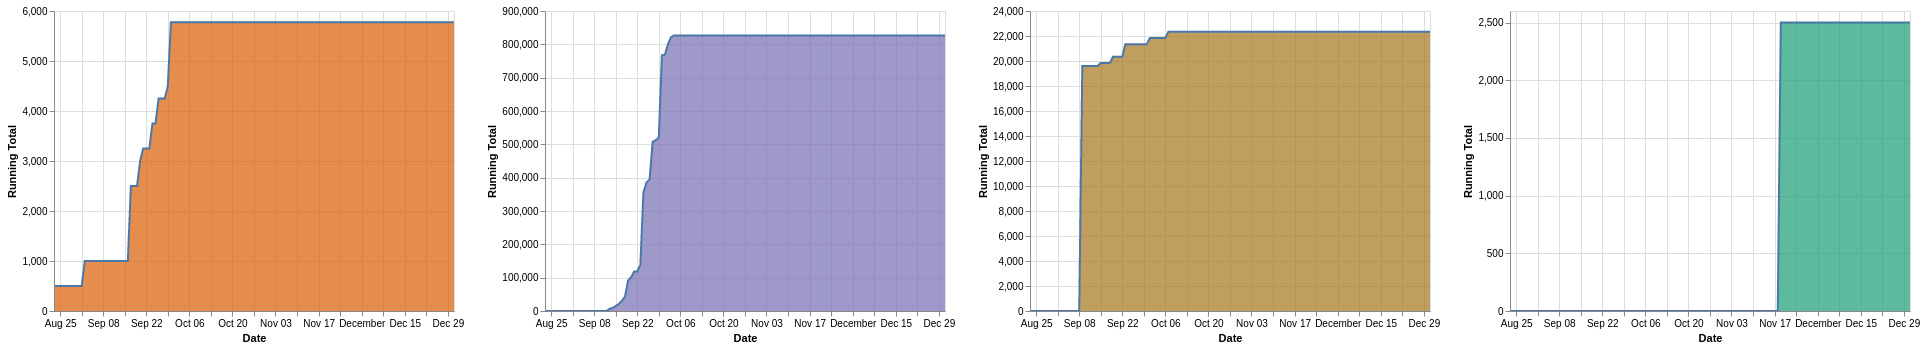

In [14]:
pf_chart = alt.Chart(pfluger).mark_area(
    color='#7570B3',
    line=True
).encode(
    x='Date:T',
    y='Running Total'
)
h_chart = alt.Chart(hogg).mark_area(
    color='#D95F02',
    line=True
).encode(
    x='Date:T',
    y='Running Total'
)
br_chart = alt.Chart(breyman).mark_area(
    color='#1B9E77',
    line=True
).encode(
    x='Date:T',
    y='Running Total'
)
ba_chart = alt.Chart(bartlett).mark_area(
    color='#A6761D',
    line=True
).encode(
    x='Date:T',
    y='Running Total'
)

alt.hconcat(h_chart, pf_chart, ba_chart, br_chart)

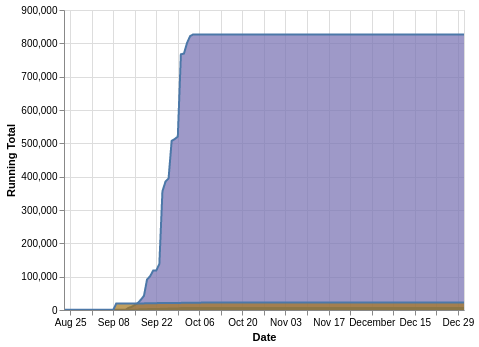

In [15]:
pf_chart + h_chart + br_chart + ba_chart

## Senate

Reset min_date for earliest record for candidates in this race

In [16]:
min_date_senate = '2018-09-26'

idx_senate = pd.date_range(min_date_senate, max_date, freq='D')

In [17]:
cornyn = cornyn.reindex(idx_senate, fill_value=0).rename_axis('Date')
hegar = hegar.reindex(idx_senate, fill_value=0).rename_axis('Date')

In [21]:
cornyn_amount_series = pd.Series(cornyn['Amount'])
hegar_amount_series = pd.Series(hegar['Amount'])

c_cuml = cornyn_amount_series.cumsum()
heg_cuml = hegar_amount_series.cumsum()

cornyn['Running Total'] = c_cuml
hegar['Running Total'] = heg_cuml

cornyn.reset_index(inplace=True)
hegar.reset_index(inplace=True)
hegar.tail()

,level_0,index,Date,Amount,Running Total
457,457,457,2019-12-27,0.0,2470937.09
458,458,458,2019-12-28,0.0,2470937.09
459,459,459,2019-12-29,0.0,2470937.09
460,460,460,2019-12-30,0.0,2470937.09
461,461,461,2019-12-31,0.0,2470937.09


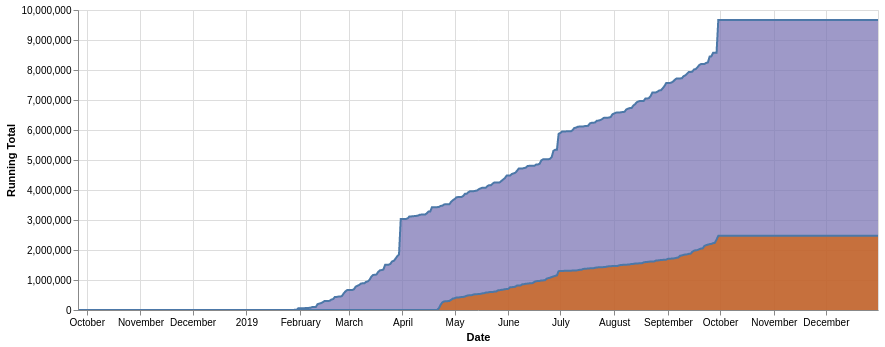

In [19]:
co_chart = alt.Chart(cornyn, width=800).mark_area(
    color='#7570B3',
    line=True
).encode(
    x='Date:T',
    y='Running Total'
)
he_chart = alt.Chart(hegar, width=800).mark_area(
    color='#D95F02',
    line=True
).encode(
    x='Date:T',
    y='Running Total'
)

co_chart + he_chart

In [45]:
hegar_sum = hegar['Running Total'].max()
hegar_obj = {'Name':'MJ Hegar', 'Amount':hegar_sum}
hegar_single_df = pd.DataFrame(hegar_obj, index=[0])
hegar_single_df

,Name,Amount
0,MJ Hegar,2470937.09


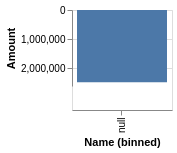

In [79]:
hegar_s_bar = alt.Chart(hegar_single_df, width=100, height=100).mark_bar().encode(
    alt.Y('Amount:Q', scale=alt.Scale(range=[0,76])),
    alt.X('Name:N', bin=alt.Bin(extent=[0, 2])),
)

hegar_s_bar